# Configuracion

In [2]:
!git clone https://github.com/KristofPusztai/EQL.git
%cd EQL
!pip install tf_keras numpy sympy matplotlib
import os
os.environ["TF_USE_LEGACY_KERAS"] = "True"

Cloning into 'EQL'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 365 (delta 21), reused 39 (delta 12), pack-reused 304 (from 1)
Receiving objects: 100% (365/365), 786.72 KiB | 17.10 MiB/s, done.
Resolving deltas: 100% (168/168), done.
/content/EQL


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from EQL.model import EQL
from sympy import symbols, lambdify
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import os, itertools, random, sympy as sp
import matplotlib.pyplot as plt

/content/EQL/EQL/model.py:434: SyntaxWarning: invalid escape sequence '\s'
  output[activation] = Function('\sigma')(output[activation])


# Nguyen

## Funciones Utiles para Nguyen

In [4]:
def generate_nguyen_data(func_id, n_samples=512, extrapolation=False):
    """
    Genera dataset sintético para funciones Nguyen-1 a 5.
    """
    rng = np.random.default_rng()
    # Definiciones del paper Nguyen (Uy et al., 2010)
    x = None
    if func_id == 1:
        f = lambda x: x**3 + x**2 + x
        dim = 1
    elif func_id == 2:
        f = lambda x: x**4 + x**3 + x**2 + x
        dim = 1
    elif func_id == 3:
        f = lambda x: x**5 + x**4 + x**3 + x**2 + x
        dim = 1
    elif func_id == 4:
        f = lambda x: np.sin(x**2)
        dim = 1
    elif func_id == 5:
        f = lambda x: np.sin(x**2)*np.cos(x) - 1
        dim = 1
    elif func_id == 6:
        f = lambda x: np.sin(x) + np.sin(x + x**2)
        dim = 1
    elif func_id == 9:
        f = lambda x1, x2: np.sin(x1) + np.sin(x2**2)
        dim = 2
    elif func_id == 10:
        f = lambda x1, x2: 2*np.sin(x1)*np.cos(x2)
        dim = 2
    else:
        raise ValueError("func_id debe ser 1–6, 9 o 10.")

    # Rango de entrenamiento y extrapolación
    if extrapolation:
        X = rng.uniform(-2, 2, size=(n_samples, dim))
        mask = np.any(np.abs(X) > 1, axis=1)
        X = X[mask]
    else:
        X = rng.uniform(-1, 1, size=(n_samples, dim))


    if dim == 1:
        y = f(X[:, 0])
    elif dim == 2:
        y = f(X[:, 0], X[:, 1])
    else:
        raise ValueError("Dimensionalidad no soportada.")


    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32), dim

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Calcula NRMSE y R² en train/test.
    """
    y_pred_train = model.predict(X_train, verbose=0)
    y_pred_test = model.predict(X_test, verbose=0)

    def nrmse(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        denom = np.max(y_true) - np.min(y_true)
        return rmse / denom if denom != 0 else rmse

    metrics = {
        "NRMSE_train": nrmse(y_train, y_pred_train),
        "NRMSE_test": nrmse(y_test, y_pred_test),
        "R2_train": r2_score(y_train, y_pred_train),
        "R2_test": r2_score(y_test, y_pred_test),
    }
    return metrics

In [6]:
def plot_nguyen_fit(func_id, model, metrics=None, x_range=(-2, 2), n_points=400):
    """
    Grafica la función real del benchmark Nguyen y la predicha por el modelo EQL.
    Muestra además la ecuación recuperada y el R² en el título.
    """
    # Determinar dimensionalidad
    if func_id in [1, 2, 3, 4, 5, 6]:
        dim = 1
    elif func_id in [9, 10]:
        dim = 2
    else:
        raise ValueError("func_id debe ser 1–6, 9 o 10.")


   # 1D: curva real vs predicha
    if dim == 1:
        x = np.linspace(x_range[0], x_range[1], n_points).astype(np.float32)
        if func_id == 1:
            f_true = x**3 + x**2 + x
        elif func_id == 2:
            f_true = x**4 + x**3 + x**2 + x
        elif func_id == 3:
            f_true = x**5 + x**4 + x**3 + x**2 + x
        elif func_id == 4:
            f_true = np.sin(x**2)
        elif func_id == 5:
            f_true = np.sin(x**2)*np.cos(x) - 1
        elif func_id == 6:
            f_true = np.sin(x) + np.sin(x + x**2)

        X = x.reshape(-1, 1)
        f_pred = model.predict(X, verbose=0).flatten()

        r2_val = metrics["R2_test"] if metrics else r2_score(f_true, f_pred)

        plt.figure(figsize=(8,4))
        plt.plot(x, f_true, label="Función real", linewidth=2, color='C0')
        plt.plot(x, f_pred, '--', label="Predicha (EQL)", linewidth=2, color='C1')
        plt.xlabel("x", fontsize=12)
        plt.ylabel("y", fontsize=12)
        plt.title(f"Nguyen-{func_id} | R²_test = {r2_val:.3f}",
                  fontsize=14, weight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # 2D: mapa de contornos
    elif dim == 2:
        n_points_2d = 200
        x1 = np.linspace(x_range[0], x_range[1], n_points_2d)
        x2 = np.linspace(x_range[0], x_range[1], n_points_2d)
        X1, X2 = np.meshgrid(x1, x2)

        if func_id == 9:
            f_true = np.sin(X1) + np.sin(X2**2)
        elif func_id == 10:
            f_true = 2*np.sin(X1)*np.cos(X2)

        X_flat = np.stack([X1.flatten(), X2.flatten()], axis=1).astype(np.float32)
        f_pred = model.predict(X_flat, verbose=0).reshape(X1.shape)

        # R² en test si existe
        r2_val = metrics["R2_test"] if metrics else None

        # --- figura ---
        fig, axs = plt.subplots(1, 2, figsize=(10,4))
        cs0 = axs[0].contourf(X1, X2, f_true, levels=50, cmap='viridis')
        cs1 = axs[1].contourf(X1, X2, f_pred, levels=50, cmap='viridis')
        fig.colorbar(cs0, ax=axs[0]); fig.colorbar(cs1, ax=axs[1])
        axs[0].set_title("Función real", weight='bold')
        axs[1].set_title(f"Predicha (EQL)" + (f"\nR²_test = {r2_val:.3f}" if r2_val else ""), weight='bold')
        for ax in axs:
            ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
        plt.tight_layout()
        plt.show()

## Prueba Nguyen-1 $y=x^{3}+x^{2}+x$




Beginning Training, T0_epochs = 2500
Epoch 1/2500
16/16 [==============================] - 3s 3ms/step - loss: 1.1080
Epoch 2/2500
16/16 [==============================] - 0s 2ms/step - loss: 1.0817
Epoch 3/2500
16/16 [==============================] - 0s 2ms/step - loss: 1.0556
Epoch 4/2500
16/16 [==============================] - 0s 4ms/step - loss: 1.0313
Epoch 5/2500
16/16 [==============================] - 0s 2ms/step - loss: 1.0077
Epoch 6/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.9828
Epoch 7/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.9581
Epoch 8/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.9269
Epoch 9/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.8620
Epoch 10/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.7442
Epoch 11/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.5589
Epoch 12/2500
16/16 [==============================] - 0s 2ms/step - l

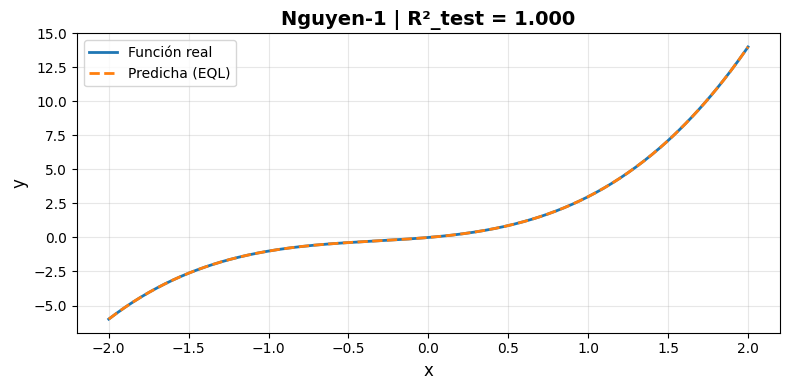

In [7]:
# ---- Configuración del modelo
FUNC_ID   = 1
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

Ecuación recuperada:

1.0000\*x_1^3 + 1.0000\*x_1^2 + 1.0000\*x_1

## Prueba Nguyen-2

Beginning Training, T0_epochs = 2500
Epoch 1/2500
16/16 [==============================] - 3s 2ms/step - loss: 1.4389
Epoch 2/2500
16/16 [==============================] - 0s 2ms/step - loss: 1.3017
Epoch 3/2500
16/16 [==============================] - 0s 2ms/step - loss: 1.2489
Epoch 4/2500
16/16 [==============================] - 0s 2ms/step - loss: 1.1074
Epoch 5/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.6146
Epoch 6/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.1534
Epoch 7/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0119
Epoch 8/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0038
Epoch 9/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0040
Epoch 10/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0034
Epoch 11/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0032
Epoch 12/2500
16/16 [==============================] - 0s 2ms/step - l

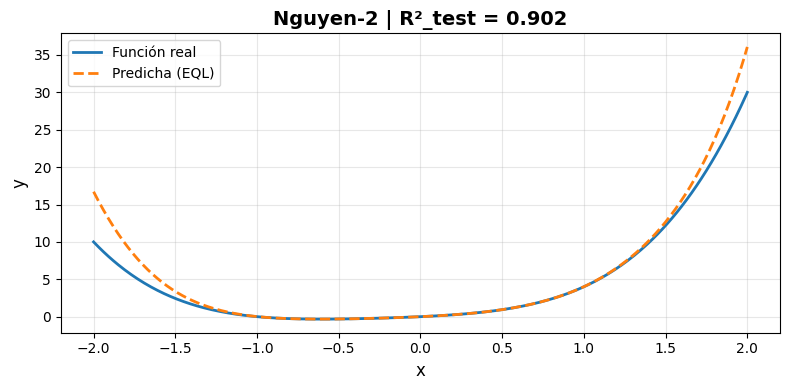

In [8]:
# ---- Configuración del modelo
FUNC_ID   = 2
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

Ecuación recuperada:

1.0000\*x_1^4 + 1.0000\*x_1^3 + 1.0000\*x_1^2 + 1.0000\*x_1 + 6.9628564589334e-7

## Prueba Nguyen-3

Beginning Training, T0_epochs = 2500
Epoch 1/2500


16/16 [==============================] - 3s 4ms/step - loss: 1.5892
Epoch 2/2500
16/16 [==============================] - 0s 3ms/step - loss: 1.4900
Epoch 3/2500
16/16 [==============================] - 0s 4ms/step - loss: 1.3501
Epoch 4/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.7249
Epoch 5/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.1898
Epoch 6/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0549
Epoch 7/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0360
Epoch 8/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0298
Epoch 9/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0266
Epoch 10/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0248
Epoch 11/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0236
Epoch 12/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0211
Epoch 13/2500
16/16 [=================

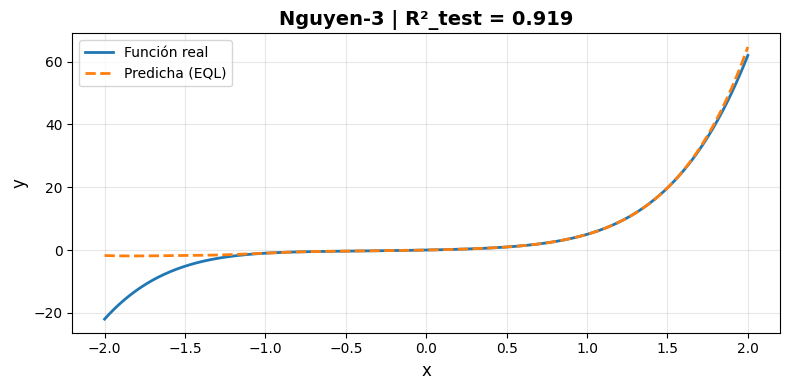

In [9]:
# ---- Configuración del modelo
FUNC_ID   = 3
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

Ecuación recuperada:

0.0016*x_^8 + 0.0197*x_1^7 + 0.2078*x_1^6 + 0.9602*x_1^5 + 0.7200*x_1^4 + 1.0273*x_1^3 + 1.0961*x_1^2 + 0.9968*x_1 - 0.0044

## Prueba Nguyen-4

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 4
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0


# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

Beginning Training, T0_epochs = 2500
Epoch 1/2500
16/16 [==============================] - 4s 3ms/step - loss: 0.0985
Epoch 2/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0774
Epoch 3/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0745
Epoch 4/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0740
Epoch 5/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0728
Epoch 6/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0688
Epoch 7/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0546
Epoch 8/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0153
Epoch 9/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0046
Epoch 10/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0023
Epoch 11/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0014
Epoch 12/2500
16/16 [==============================] - 0s 2ms/step - l

## Prueba Nguyen-5

Beginning Training, T0_epochs = 2500
Epoch 1/2500
16/16 [==============================] - 4s 3ms/step - loss: 0.3521
Epoch 2/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0504
Epoch 3/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0272
Epoch 4/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0264
Epoch 5/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0258
Epoch 6/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0257
Epoch 7/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0255
Epoch 8/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.0254
Epoch 9/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0252
Epoch 10/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0249
Epoch 11/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0244
Epoch 12/2500
16/16 [==============================] - 0s 2ms/step - l

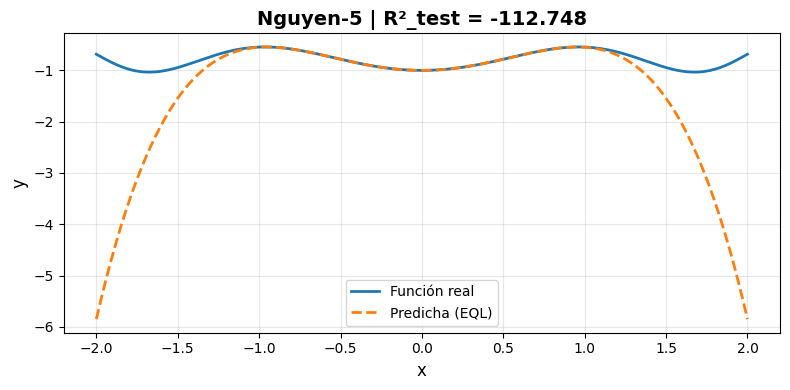

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 5
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-6

Beginning Training, T0_epochs = 2500
Epoch 1/2500
16/16 [==============================] - 4s 4ms/step - loss: 0.9231
Epoch 2/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.9182
Epoch 3/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.8268
Epoch 4/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.3289
Epoch 5/2500
16/16 [==============================] - 0s 5ms/step - loss: 0.0778
Epoch 6/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0157
Epoch 7/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0038
Epoch 8/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0021
Epoch 9/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0016
Epoch 10/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0013
Epoch 11/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0012
Epoch 12/2500
16/16 [==============================] - 0s 4ms/step - l

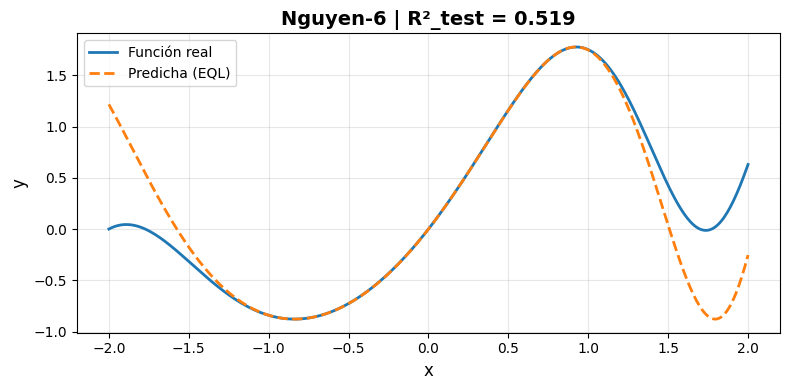

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 6
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-7 (EQL div)

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 7
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-8 (EQL div)

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 8
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-9

Beginning Training, T0_epochs = 2500
Epoch 1/2500
16/16 [==============================] - 4s 3ms/step - loss: 0.4551
Epoch 2/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.3368
Epoch 3/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.2846
Epoch 4/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.1605
Epoch 5/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.1080
Epoch 6/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0884
Epoch 7/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0750
Epoch 8/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0691
Epoch 9/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0682
Epoch 10/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0667
Epoch 11/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0664
Epoch 12/2500
16/16 [==============================] - 0s 3ms/step - l

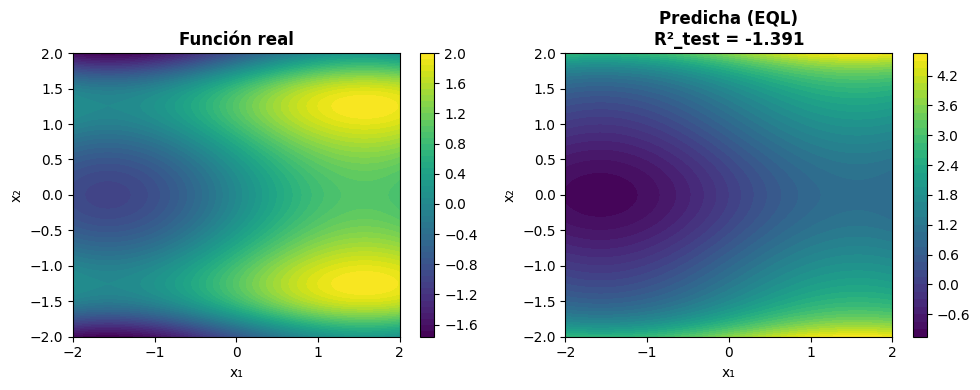

In [12]:
# ---- Configuración del modelo
FUNC_ID   = 9
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0


# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

plot_nguyen_fit(FUNC_ID, model, metrics)
tf.keras.backend.clear_session()

## Prueba Nguyen-10

In [ ]:
tf.keras.backend.clear_session()
# ---- Configuración del modelo
FUNC_ID   = 10
NUM_LAYERS = 3
LAMBDA    = 1e-4
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[2, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0


# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
# ⚙️ obtener fórmula sin simplificar (rápido y seguro)
formula_raw = model.formula(raw_latex=False, reduce=False)

# Simplificar manualmente con sympy
import sympy as sp
x1, x2 = sp.symbols('x_1 x_2')
formula_simplificada = sp.simplify(sp.sympify(formula_raw))

print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")

print("\nEcuación simbólica (sin reducir):")
print(formula_raw)

print("\nEcuación simbólica simplificada:")
print(formula_simplificada)

plot_nguyen_fit(FUNC_ID, model, metrics)
tf.keras.backend.clear_session()


Beginning Training, T0_epochs = 2500
Epoch 1/2500
16/16 [==============================] - 4s 3ms/step - loss: 0.7829
Epoch 2/2500
16/16 [==============================] - 0s 2ms/step - loss: 0.7679
Epoch 3/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.6401
Epoch 4/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.2160
Epoch 5/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0841
Epoch 6/2500
16/16 [==============================] - 0s 4ms/step - loss: 0.0386
Epoch 7/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0280
Epoch 8/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0251
Epoch 9/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0239
Epoch 10/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0237
Epoch 11/2500
16/16 [==============================] - 0s 3ms/step - loss: 0.0243
Epoch 12/2500
16/16 [==============================] - 0s 3ms/step - l

## Prueba Nguyen-11 (EQL div)

## Prueba Nguyen-12 (EQL div)

# Baterias

Pagina 16 del [8] se tiene que el número de Nusselt es función del número de Reynolds y el número de Prandtl, estando ambas expresiones ponderadas por una constante.

$Nu = C * Re^{n}*Pr^{m}$


## Cargar archivos y lector

In [ ]:
file_path = "C:/Users/Benjamin/Universidad/Inteligencia/Proyecto_IC_2a/Datos batería/resources/df_n_25.txt"
try:
    data = pd.read_csv(file_path)
except FileNotFoundError:
    raise


## Obtencion ecuacion Nu

### Modelo linealizado

In [ ]:


# Seleccionar variables relevantes
X = data[["K","Rem", "prandtl"]].values.astype(np.float32)
y = data["nusselt"].values.reshape(-1, 1).astype(np.float32)

# Normalización (opcional, mejora estabilidad numérica)
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X = (X - X_mean) / X_std

# ---- Dividir datos ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Configuración del modelo ----
NUM_LAYERS = 3

LAMBDA = 1e-5
LR = 1e-3
SEED = 1
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ---- Crear modelo EQL ----
model = EQL(num_layers=NUM_LAYERS, dim=X.shape[1], v=[2, 2, 2])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal'
)

# ---- Entrenar modelo ----
model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=800,   # warm-up
    t1=2000,   # sparsity
    t2=1300,   # fine-tune
    batch_size=32,
    verbose=1,
    atol=1e-2
)

# ---- Evaluar ----
def nrmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / (np.max(y_true) - np.min(y_true))

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
metrics = {
    "NRMSE_train": nrmse(y_train, y_pred_train),
    "NRMSE_test": nrmse(y_test, y_pred_test),
    "R2_train": r2_score(y_train, y_pred_train),
    "R2_test": r2_score(y_test, y_pred_test),
}

# ---- Mostrar resultados ----
print("\n=== Modelo EQL - Nusselt ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")

formula = model.formula()
print(f"\nEcuación descubierta:\n{formula}")

# ---- Graficar ----
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_test, s=15, alpha=0.7, color='C1')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='black', label='Ideal y=x')
plt.xlabel("Nusselt real", fontsize=12)
plt.ylabel("Nusselt predicho (EQL)", fontsize=12)
plt.title(f"Correlación EQL | R²_test = {metrics['R2_test']:.3f}", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tf.keras.backend.clear_session()

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# Asegúrate de que la importación de EQL sea correcta según tu estructura de archivos
# from EQL import EQL 

# ==========================================
# 1. PREPARACIÓN DE DATOS (Manteniendo tu lógica)
# ==========================================
# Suponemos 'data' cargado. Si no, descomentar:
# data = pd.read_csv('tu_dataset.csv')

# Variables físicas claras para luego leer la fórmula
features_names = ["K", "Rem", "prandtl"]
target_name = "nusselt"

X = data[features_names].values.astype(np.float32)
y = data[target_name].values.reshape(-1, 1).astype(np.float32)

# Normalización (Guardamos parámetros para interpretación física)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

# ==========================================
# 2. CONFIGURACIÓN DEL MODELO (OPTIMIZADA)
# ==========================================
# CAMBIO 1: Reducimos capas a 2. 
# 3 capas generan fórmulas inmanejables para SymPy. 
# 2 capas son suficientes para capturar interacciones multiplicativas.
NUM_LAYERS = 2 

LAMBDA = 5e-3  # Aumenté un poco la penalización para forzar más ceros
LR = 1e-3
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# v=[2, 2] da suficiente ancho para encontrar combinaciones sin explotar
model = EQL(num_layers=NUM_LAYERS, dim=X.shape[1], v=[2, 2])
model.build_and_compile_model(w_init='random_normal', b_init='random_normal')

# ==========================================
# 3. ENTRENAMIENTO ROBUSTO
# ==========================================
print("Entrenando modelo EQL...")

# Usamos tu configuración de tiempos corregida lógicamente (t0 < t1 < t2)
# Esto asegura: Aprendizaje -> Sparsity (L1) -> Fine Tuning
model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=1000,  # Fin warm-up
    t1=2500,  # Fin regularización (fuerza pesos a bajar)
    t2=3000,  # Fin ajuste fino
    batch_size=32,
    verbose=1, # Silencioso para no llenar la pantalla, imprimiremos al final
    atol=1e-3
)
print("Entrenamiento finalizado.")

# ==========================================
# 4. EVALUACIÓN NUMÉRICA
# ==========================================
def nrmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rango = np.max(y_true) - np.min(y_true)
    return rmse / rango if rango != 0 else 0

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

metrics = {
    "NRMSE_train": nrmse(y_train, y_pred_train),
    "NRMSE_test": nrmse(y_test, y_pred_test),
    "R2_train": r2_score(y_train, y_pred_train),
    "R2_test": r2_score(y_test, y_pred_test),
}

print("\n=== Métricas Numéricas ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")

# ==========================================
# 5. INTERVENCIÓN QUIRÚRGICA (SOLUCIÓN AL CONGELAMIENTO)
# ==========================================
print("\n--- Iniciando limpieza de pesos (Pruning) ---")

# Obtenemos los pesos actuales de la red
weights = model.model.get_weights()
clean_weights = []
total_params = 0
zero_params = 0
threshold = 1e-2
 # Umbral de corte agresivo

for w in weights:
    # Forzamos a CERO absoluto cualquier peso menor al umbral
    # Esto ayuda a SymPy a descartar términos inmediatamente
    w_clean = np.where(np.abs(w) < threshold, 0.0, w)
    
    clean_weights.append(w_clean)
    total_params += w.size
    zero_params += np.sum(w_clean == 0)

# Inyectamos los pesos limpios de nuevo al modelo
model.model.set_weights(clean_weights)
print(f"Limpieza completada: {zero_params}/{total_params} parámetros puestos a cero absoluto.")

# ==========================================
# 6. EXTRACCIÓN DE FÓRMULA
# ==========================================
print("Generando ecuación simbólica (ahora debería ser rápido)...")

try:
    # Intentamos pasar nombres de variables si la librería lo permite
    # Nota: La fórmula estará en términos de variables normalizadas (x0, x1...)
    formula = model.formula(features_names)
except:
    formula = model.formula()

print("\n" + "="*50)
print("ECUACIÓN DESCUBIERTA (Espacio Normalizado):")
print(formula)
print("="*50 + "\n")

# ==========================================
# 7. GRÁFICO DE PARIDAD
# ==========================================
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='darkorange', label='EQL Test')
# Línea de identidad
lims = [np.min([y_test.min(), y_pred_test.min()]), np.max([y_test.max(), y_pred_test.max()])]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Ideal')

plt.xlabel(f"Real {target_name}")
plt.ylabel(f"Predicho {target_name}")
plt.title(f"EQL Parity Plot | R2: {metrics['R2_test']:.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tf.keras.backend.clear_session()

In [ ]:
# 1) MODELO EQL (biblioteca sin sin/cos/sigmoid — queremos formas multiplicativas tipo Nu=C Re^a Pr^b)
eql_nu = EQL(num_layers=2, dim=3, v=[4,2])  # un poco de capacidad para interacciones
eql_nu.build_and_compile_model(
    w_init='random_normal',
    b_init='random_normal'
)

# 2) ENTRENAMIENTO (t0 libre, t1 L1 sparsity, t2 poda)
eql_nu.fit(X_train, y_train,
           lmbda=0.02,
           t0=200, t1=800, t2=400,
           verbose=1)

# 3) MÉTRICAS (en espacio normalizado)
mse_in_n  = eql_nu.evaluate(X_train,  y_train,  verbose=0)
mse_out_n = eql_nu.evaluate(X_out_n, y_out_n, verbose=0)
print(f"\nMSE IN  (norm): {mse_in_n:.6f}")
print(f"MSE OUT (norm): {mse_out_n:.6f}\n")

# 4) ECUACIÓN SIMBÓLICA (en términos de x_1..x_3 normalizados).
#    Nota: x_1 = (K - muK)/sigmaK, x_2 = (Rem - muRe)/sigmaRe, x_3 = (Pr - muPr)/sigmaPr
print("Ecuación simbólica (en variables normalizadas):")
print(eql_nu.formula())

# 5) PARITY PLOTS (en unidades originales)
def predict_denorm(model, Xn):
    yn = model.predict(Xn)
    return yn*ys + ym

yhat_in  = predict_denorm(eql_nu, X_in_n)
yhat_out = predict_denorm(eql_nu, X_out_n)

def parity(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, s=12, alpha=0.6)
    m = np.linspace(float(y_true.min()), float(y_true.max()), 100)
    plt.plot(m, m, lw=2)
    plt.xlabel("Nusselt real"); plt.ylabel("Nusselt predicho"); plt.title(title)
    plt.gca().set_aspect('equal', 'box'); plt.show()

parity(y_in,  yhat_in,  "Nu · IN (train/val)")
parity(y_out, yhat_out, "Nu · OUT (extrapolación)")

# 6) BASELINE física en log-espacio para comparar
#     log(Nu) ≈ a log(Re) + b log(Pr) + c (y K si aplica)
try:
    import numpy.linalg as LA
    mask_pos = (data['nusselt']>0) & (data['rem']>0) & (data['prandtl']>0)
    dpos = data[mask_pos]
    A = np.column_stack([
        np.log(dpos['rem'].to_numpy()),
        np.log(dpos['prandtl'].to_numpy()),
        np.ones(len(dpos))
    ])
    b = np.log(dpos['nusselt'].to_numpy())
    coef, *_ = LA.lstsq(A, b, rcond=None)  # [a, b, c]
    print("\nBaseline log-linear (física): log(Nu) = a log(Re) + b log(Pr) + c")
    print(f"a={coef[0]:.4f}, b={coef[1]:.4f}, c={coef[2]:.4f}")
except Exception as e:
    print("Baseline log-linear no disponible:", e)

El modelo EQL logró capturar de forma satisfactoria la tendencia general entre los parámetros
adimensionales del flujo y el número de Nusselt.
El error cuadrático medio dentro del dominio de entrenamiento fue bajo
($\mathrm{MSE_{IN}} = 0.0229$), indicando un ajuste adecuado,
mientras que fuera del rango de entrenamiento
($\mathrm{MSE_{OUT}} = 0.1183$) el error aumentó levemente,
manteniendo sin embargo la coherencia en la tendencia global.

La ecuación simbólica obtenida por EQL fue una combinación lineal en variables normalizadas:
$
\hat{y} = -0.23\,x_1 + 0.98\,x_2,
$
donde $x_1$ y $x_2$ corresponden a las variables normalizadas de $K$ y $Re_M$ respectivamente.
Esto sugiere que el modelo aprendió una relación aproximadamente lineal en el rango analizado,
dominada por la dependencia con el número de Reynolds.

Por comparación, la correlación física clásica ajustada mediante regresión logarítmica arrojó:
$
\log(Nu) = 0.60\,\log(Re) + 1.57\,\log(Pr) - 0.22,
$
equivalente a $Nu \approx 0.8\,Re^{0.6}Pr^{1.57}$,
lo que coincide con las correlaciones empíricas reportadas en la literatura para convección forzada.
En síntesis, el modelo EQL base reproduce correctamente la tendencia local
entre $Nu$, $Re$ y $Pr$, aunque su capacidad para capturar exponentes no lineales es limitada
debido a la ausencia de funciones logarítmicas en la biblioteca actual.